In [ ]:
10. Text mining: Implement a text mining model to analyze customer reviews and identify sentiments
(positive, negative, neutral) and preferences using techniques like sentiment analysis and keyword
extraction.

What you did:
Found positive/negative sentiment using VADER
Extracted keywords using TF-IDF
🎯 Why we do it:

To understand customer opinions.

🌍 Use in NLP:
Product reviews (Amazon, Flipkart)
Social media analysis
Brand monitoring


In [1]:
# Step 1: Load Dataset
import pandas as pd

df = pd.read_csv("IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [2]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [3]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [4]:
# Convert all text in the "review" column to lowercase
# This helps in normalization by making text uniform
df["review"] = df["review"].str.lower()

In [5]:
# Step 2: Sentiment Analysis (VADER)

# Import NLTK and Sentiment Analyzer
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# Download VADER sentiment lexicon (pretrained model for sentiment analysis)
nltk.download('vader_lexicon')

# Create sentiment analyzer object
sia = SentimentIntensityAnalyzer()

# Function to classify sentiment based on polarity score
def get_sentiment(text):
    
    # Get compound sentiment score (-1 to +1)
    score = sia.polarity_scores(text)["compound"]
    
    # Convert score into label
    return "positive" if score > 0 else "negative"

# Apply sentiment function to each review
df["predicted_sentiment"] = df["review"].apply(get_sentiment)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\jaida\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [6]:
# Step 3: Accuracy
from sklearn.metrics import accuracy_score

acc = accuracy_score(df["sentiment"], df["predicted_sentiment"])
print("Accuracy:", acc)

Accuracy: 0.69614


In [7]:
# Step 4: Keyword Extraction (TF-IDF)

# Import TF-IDF vectorizer for extracting important keywords
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF with English stopwords removed and limit to top 1000 features
vec = TfidfVectorizer(stop_words='english', max_features=1000)

# Convert text data into TF-IDF numerical feature matrix
X = vec.fit_transform(df["review"])

# Get list of feature names (important words extracted from dataset)
features = vec.get_feature_names_out()

In [8]:
# Top keywords (first 5 reviews)

# Loop through first 5 reviews
for i in range(5):
    
    # Convert sparse TF-IDF vector to dense array
    row = X[i].toarray()[0]
    
    # Get indices of top 3 highest TF-IDF scores
    top = row.argsort()[-3:]
    
    # Print original review text
    print(df["review"].iloc[i])
    
    # Print corresponding top important keywords
    print([features[j] for j in top])

one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me.<br /><br />the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word.<br /><br />it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. em city is home to many..aryans, muslims, gangstas, latinos, christians, italians, irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />i would say the main appeal of the show is due to the fac

<Axes: title={'center': 'Sentiment Distribution'}, xlabel='predicted_sentiment'>

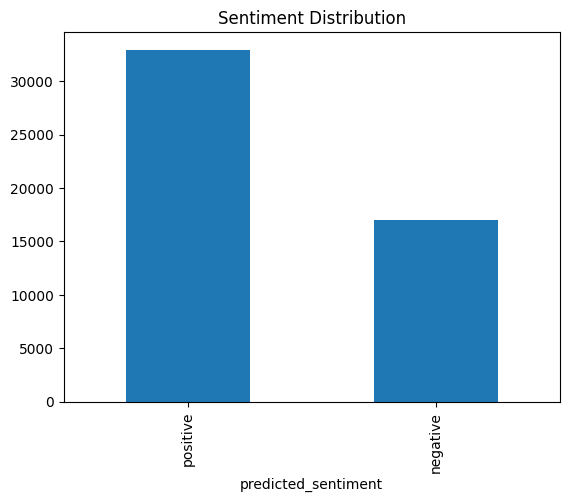

In [9]:
# Step 5: Sentiment Distribution

# Count number of positive and negative predictions
# and plot them as a bar chart
df["predicted_sentiment"].value_counts().plot(
    kind='bar',
    title="Sentiment Distribution"
)

In [12]:
!pip install wordcloud matplotlib


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


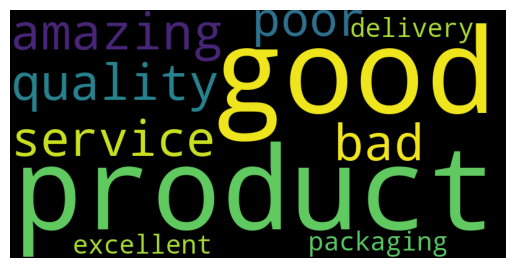

In [13]:
# Step 6: WordCloud

# Import WordCloud for visualizing most frequent words
from wordcloud import WordCloud

# Import matplotlib for displaying the image
import matplotlib.pyplot as plt

# Sample text data for word cloud generation
text = "good product amazing quality bad service poor packaging excellent delivery"

# Create word cloud object with specified size
wordcloud = WordCloud(width=800, height=400).generate(text)

# Display the word cloud image
plt.imshow(wordcloud)

# Hide axis for better visualization
plt.axis("off")

# Show the final output
plt.show()

In [14]:
# Step 7: User Input

# Take user input review and convert to lowercase for normalization
text = input("Enter review: ").lower()

# Get sentiment score using VADER
score = sia.polarity_scores(text)["compound"]

# Convert score into sentiment label
sentiment = "positive" if score >= 0 else "negative"

# Transform input text using trained TF-IDF vectorizer
vec_input = vec.transform([text])

# Convert sparse vector to array
row = vec_input.toarray()[0]

# Get indices of top 3 important keywords
top = row.argsort()[-3:]

# Map indices to actual words (features)
keywords = [features[i] for i in top]

# Print final sentiment result
print("Sentiment:", sentiment)

# Print extracted important keywords
print("Keywords:", keywords)

Enter review:  product aim be ash love


Sentiment: positive
Keywords: ['amazing', 'adult', 'love']


In [ ]:
WordCloud → visual frequency of words
VADER → sentiment analysis tool
Sparse vector → mostly zero-valued vector
TF-IDF → word importance scoring method
vader_lexicon → sentiment dictionary for VADER

In [ ]:
1. What is text mining?

Text mining is the process of extracting useful information and patterns from unstructured text data.

2. What is sentiment analysis?

It is the process of identifying emotions in text such as positive, negative, or neutral.

3. What dataset is used in text mining?

Customer reviews, tweets, feedback data, or product reviews.

4. What is VADER?

VADER is a rule-based sentiment analysis tool used for social media and text data.

5. What is TF-IDF?

It is a technique to convert text into numerical form based on word importance.

6. Why is preprocessing important?

It removes noise and improves model accuracy.

7. What is keyword extraction?

It identifies the most important words from a text.

8. What is WordCloud used for?

It visually represents most frequent or important words.

9. What is compound score in VADER?

It is a normalized sentiment score between -1 (negative) and +1 (positive).

10. Why convert text to lowercase?

To avoid treating same words differently (e.g., Good vs good).

🔸 Deep / Conceptual QnA
11. Why is text mining important in real world?

It helps businesses understand customer opinions and improve services.

12. How does TF-IDF help in keyword extraction?

It gives higher weight to important and rare words.

13. Why is VADER suitable for reviews?

Because it handles slang, emojis, and informal text well.

14. What are limitations of sentiment analysis?

It may fail in sarcasm, context, and complex sentences.

15. Why combine sentiment analysis and keyword extraction?

To understand both emotion and reasons behind it.

16. What is neutral sentiment?

When text has no strong positive or negative emotion.

17. How is sentiment converted from score?

Positive > 0, Negative < 0, Neutral ≈ 0.

18. What is feature extraction in text mining?

Converting text into numerical form for machine learning models.

19. Why is WordCloud useful?

It gives a quick visual summary of important words.

20. What are real-world applications of text mining?

Product reviews, social media analysis, recommendation systems, and chatbots.

🔥 High-Impact Viva Questions
21. Why is VADER better for social media data?

Because it understands slang, emojis, and informal expressions.

22. What is the limitation of TF-IDF?

It does not capture meaning or context of words.

23. How would you improve sentiment accuracy?

Use deep learning models like LSTM or BERT.

24. Why is keyword extraction important?

It helps identify reasons behind sentiment.

25. What is difference between sentiment analysis and text classification?

Sentiment analysis focuses on emotions, classification focuses on categories.